# ASP `sfs --model-shadows`: feasibility spike, and why it's currently blocked

`notebooks/isis_shadow_spike.py` and `notebooks/gld100_banding_investigation.py` found a real,
recurring horizontal-streak artifact in ISIS `shadow`'s output on this project's GLD100 DEM, and
split it into two phenomena: a confirmed `shadow`-caching artifact (fixed by `PRESET=ACCURATE`)
and a second, genuine-looking grazing-occlusion effect that *survives* `ACCURATE`. That second
finding is itself evidence the primary streak is not simply a `shadow`-tool processing artifact --
but doesn't rule out some other systematic quirk of ISIS `shadow`'s own ray/DEM-intersection
implementation specifically (as opposed to its caching layer).

This notebook set out to test that with a second, independently-implemented shadow-mask
generator: ASP's `sfs` tool, run with `--model-shadows` and `--save-sim-intensity-only` (skips
SfS's actual iterative DEM refinement -- a single forward simulation pass, not a shape-from-shading
solve). **Verdict: blocked, not merely "not yet tried".** Every camera representation this
project can produce was tried; all either failed outright or produced a silently-degenerate
all-zero result that a direct cross-check (`mapproject`, below) proves is *not* a real geometry
problem on this project's side. See "What was tried" below for the full trail, kept because the
elimination is itself the useful finding for anyone picking this up later.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import LightSource

import trntest
from trntest import dem_ortho, illumination, render
from trntest.subprocess_utils import run_quiet

# Same candidate as isis_shadow_spike.py -- lowest sun_elevation_deg (13.6 deg) in the manifest, and
# the one the streak investigation was done against.
CANDIDATE_PRODUCT_ID = "M1327218454CE"

## Candidate, DEM, and the synthetic image+camera pair

`dem_ortho.fetch_dem_and_ortho(camera, entry.config)`, called with no `extra_footprint_lonlat_deg`
-- deliberately *not* `entry.dem_ortho_result` (which unions in `entry.crop_footprint`'s extra
AOI, producing a larger grid, 2766x2780px vs. 2424x2437px here). Matching `isis_shadow_spike.py`'s
own plain `dem_ortho.fetch_dem(camera, entry.config)` call exactly keeps this notebook's DEM on
the *same* pixel grid as that notebook's (and `gld100_banding_investigation.py`'s) row-indexed
findings, e.g. the row-1016 primary streak -- moot for this notebook's actual (blocked) outcome,
but kept so a future fix can resume the row-level comparison without re-deriving this.

`render.run_sat_sim` -- the plain pinhole/Frame TSAI camera (`camera.tsai_path`) plus its
`sat_sim`-rendered image, computed against this exact DEM/ortho pair, and (via `cam_gen`, already
part of `run_sat_sim`) the same camera as a CSM Frame model-state JSON (`render_result.csm_json`).

In [2]:
session = trntest.Session()
config = session.config

images = trntest.read_manifest("dataset_manifest.csv")
dataset = trntest.TrnTestDataSet.create(config.output_dir / "trn_dataset", images, config)
entry = dataset[CANDIDATE_PRODUCT_ID]
camera = entry.camera
print(f"candidate: {entry.edr_product}, footprint center (lon,lat): {camera.footprint_lonlat_deg['center']}")

candidate: M1327218454CE, footprint center (lon,lat): (np.float64(177.77785856883), np.float64(73.514130051066))


In [3]:
# This notebook only needs *some* valid ortho texture to drive sat_sim's render (a throwaway input
# for feeding sfs a camera+image pair, not a photometric product itself).
dem_ortho_result = dem_ortho.fetch_dem_and_ortho(camera, entry.config)
dem_result = dem_ortho.fetch_dem(camera, entry.config)
print(f"DEM: {dem_result.dem}, bbox={dem_result.bbox}, {dem_result.width}x{dem_result.height}")
assert dem_ortho_result.dem == dem_result.dem, "expected dem_ortho_result to reuse the same fetch_dem output"

render_result = render.run_sat_sim(camera, dem_ortho_result, entry.config)
print(f"synthetic TSAI camera: {camera.tsai_path}")
print(f"synthetic CSM Frame camera: {render_result.csm_json}")
print(f"sat_sim-rendered image: {render_result.rendered_tif}")

spike_dir = config.scratch_dir / "asp_sfs_shadow_spike"
spike_dir.mkdir(parents=True, exist_ok=True)

ROI center (lon,lat deg): (np.float64(177.77785856883), np.float64(73.514130051066)), bbox (local m): (-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701)
ROI size 2424x2437 px (~100.0 m/px)


WAC_EMP tile(s): WAC_EMP_643NM_P900N0000_304P


ROI center (lon,lat deg): (np.float64(177.77785856883), np.float64(73.514130051066)), bbox (local m): (-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701)
ROI size 2424x2437 px (~100.0 m/px)


DEM: /workspace/output/dem_filled-tile-0.tif, bbox=(-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701), 2424x2437


synthetic TSAI camera: /workspace/output/trn_dataset/_work/M1327218454CE/camera_frame48.tsai
synthetic CSM Frame camera: /workspace/output/render/run-camera_frame48.json
sat_sim-rendered image: /workspace/output/render/run-camera_frame48.tif


## What was tried

**1. The real ISIS WAC crop cube (`entry.crop_result`) as the image+camera input** (not run by
this notebook -- recorded from a direct trial). `sfs` rejected it outright: `"ERROR: Unusual
input file: .../M1327218454CE_crop.cub. Seems to have Isis camera type 1. Check your data. Maybe
it will work with CSM."` -- ASP's ISIS-session code doesn't support this project's WAC VIS
Pushframe camera type directly.

**2. The error's own suggestion: a CSM ISD for the real WAC camera** (also not run by this
notebook). `isis_campt.run_isd_generate_for_crop` can build one, but its own docstring (and
`isis_wac.py`'s module docstring) documents that `usgscsm`'s Pushframe `groundToImage` has a
confirmed, serious bug on exactly this camera/crop combination -- measured ~0.2-0.4 correlation
against ISIS's own native (correct) reprojection, not a minor precision gap. Building on that
known-broken path would make any resulting shadow mask uninformative at best -- not attempted.

**3. The synthetic TSAI (pinhole) camera + `sat_sim`-rendered image** (run below). `sfs` ran to
completion with no error, but logged `"Skipped image 0: ... with no data for this DEM"` and wrote
an exposure of `0` for that image -- and its `--save-sim-intensity-only` output was uniformly
`0.0` everywhere (checked directly: `min=max=mean=0.0`), i.e. no usable shadow signal at all.

**4. The synthetic camera as a CSM Frame model instead** (`render_result.csm_json`, from the same
`cam_gen` conversion `render.run_sat_sim` already does for `mapproject`) -- `sfs_usage.rst`'s own
"ISIS vs CSM" section is explicit that CSM is the *preferred* camera representation for `sfs`, not
just an ISIS workaround. Same "no data" message, same all-zero output.

**5. Ruling out the DEM-image geometry as the real cause.** Forcing a non-zero exposure directly
(`--image-exposures-prefix`, bypassing whatever `--num-samples-for-estim` sampling produced the
`0`) still gave an all-zero result -- so this isn't just a bad automatic exposure estimate, `sfs`
itself is finding zero usable DEM/image correspondence. But running ASP's own `mapproject` on the
*identical* DEM + rendered image + CSM JSON triplet (below) succeeds, with 66% valid coverage and
real terrain-shaded pixel values over a ~155km-wide region well inside this DEM's own bounds --
proof the camera-to-DEM registration itself is geometrically sound. Whatever `sfs` means by "no
data for this DEM" for this camera/DEM pairing, it isn't a real absence of overlap.

**Conclusion**: this is a genuine `sfs`-side blocker for this project's synthetic-camera pipeline,
not a config mistake correctable within this session's scope (no ASP source access to debug
further; `sfs`'s own docs/examples don't cover this exact "raw perspective render from `sat_sim`,
not `mapproject`'s own map-projected output" input shape). Left here in case a newer ASP release
or a filed upstream issue resolves it later -- see this notebook's own final markdown cell for
what to do if so.

In [4]:
azimuth_deg, elevation_deg = illumination.sun_azimuth_elevation_deg(*camera.footprint_lonlat_deg["center"], camera.et)
print(f"sun azimuth/elevation at footprint center: {azimuth_deg:.2f} / {elevation_deg:.2f} deg")

sun_angles_path = spike_dir / f"{entry.edr_product}_sun_angles.txt"
# `sfs` matches this file's image-name column against the exact path given on its own command
# line, not the bare basename (confirmed by a first attempt with just `.name`: "ERROR: Could not
# read the Sun position from file ... for image: <the full path>").
sun_angles_path.write_text(f"{render_result.rendered_tif} {azimuth_deg} {elevation_deg}\n")

# Forces a non-zero exposure directly, bypassing sfs's own (here, evidently broken) automatic
# exposure estimation -- see point 5 above. Format matches what sfs itself writes to
# "<prefix>-exposures.txt": "<image path> <value>".
manual_exposure_prefix = spike_dir / "manual"
(spike_dir / "manual-exposures.txt").write_text(f"{render_result.rendered_tif} 1.0\n")

out_prefix = spike_dir / f"{entry.edr_product}_sfs"
run_quiet(
    [
        "sfs",
        "-i",
        str(dem_result.dem),
        str(render_result.rendered_tif),
        str(render_result.csm_json),
        "--sun-angles",
        str(sun_angles_path),
        "--image-exposures-prefix",
        str(manual_exposure_prefix),
        "--crop-input-images",
        "--model-shadows",
        "--save-sim-intensity-only",
        "-o",
        str(out_prefix),
    ]
)

sim_intensity_path = out_prefix.with_name(out_prefix.name + f"-{render_result.rendered_tif.stem}-sim-intensity.tif")
assert sim_intensity_path.exists(), f"expected sfs to write {sim_intensity_path}"
with rasterio.open(sim_intensity_path) as src:
    sim_intensity = src.read(1, masked=True)
print(
    f"sfs sim-intensity: shape={sim_intensity.shape}, "
    f"min={sim_intensity.min()}, max={sim_intensity.max()}, mean={sim_intensity.mean()}"
)
if sim_intensity.max() == 0.0:
    print(
        "DEGENERATE, as documented above: sfs's own DEM/image overlap check found nothing usable "
        "for this camera, despite a real exposure override -- see the mapproject cross-check below "
        "for proof this isn't a real geometry problem on this project's side."
    )

sun azimuth/elevation at footprint center: 224.44 / 13.32 deg


sfs sim-intensity: shape=(2437, 2424), min=0.0, max=0.0, mean=0.0
DEGENERATE, as documented above: sfs's own DEM/image overlap check found nothing usable for this camera, despite a real exposure override -- see the mapproject cross-check below for proof this isn't a real geometry problem on this project's side.


## Cross-check: does the camera actually register against this DEM at all?

Runs ASP's own `mapproject` (a separate, independently-tested code path from `sfs`) on the exact
same DEM + rendered image + CSM JSON triplet just handed to `sfs`. If this also finds ~no overlap,
the DEM/camera pairing itself would be the real problem; if it finds substantial real overlap (as
it does), that isolates the "no data" verdict to `sfs`'s own overlap-detection logic specifically.

In [5]:
mapproject_check_tif = spike_dir / "mapproject_check.tif"
mapproject_check_tif.unlink(missing_ok=True)
run_quiet(
    [
        "mapproject",
        "--tr",
        "100",
        str(dem_result.dem),
        str(render_result.rendered_tif),
        str(render_result.csm_json),
        str(mapproject_check_tif),
    ]
)
with rasterio.open(mapproject_check_tif) as src:
    mapproject_val = src.read(1, masked=True)
valid_frac = (~np.ma.getmaskarray(mapproject_val)).mean()
print(f"mapproject output: shape={mapproject_val.shape}, valid-pixel fraction={valid_frac:.3f}")
print(
    "-> ASP's own mapproject finds real overlap with the identical DEM/camera/image sfs was just "
    "given, confirming the camera-to-DEM registration itself is fine."
)

mapproject output: shape=(1560, 1552), valid-pixel fraction=0.661
-> ASP's own mapproject finds real overlap with the identical DEM/camera/image sfs was just given, confirming the camera-to-DEM registration itself is fine.


## Visual sanity check of the DEM itself

Not sfs-derived (sfs produced no usable output) -- just a plain Lambertian hillshade of the same
DEM `isis_shadow_spike.py` used, kept here so this notebook still has something to look at, and
so a future retry of the sfs path (once/if the "no data" issue is resolved) can drop its own
shadow-mask panel in next to this without re-deriving the DEM/geometry setup above.

wrote /workspace/scratch/asp_sfs_shadow_spike/M1327218454CE_dem_hillshade.png


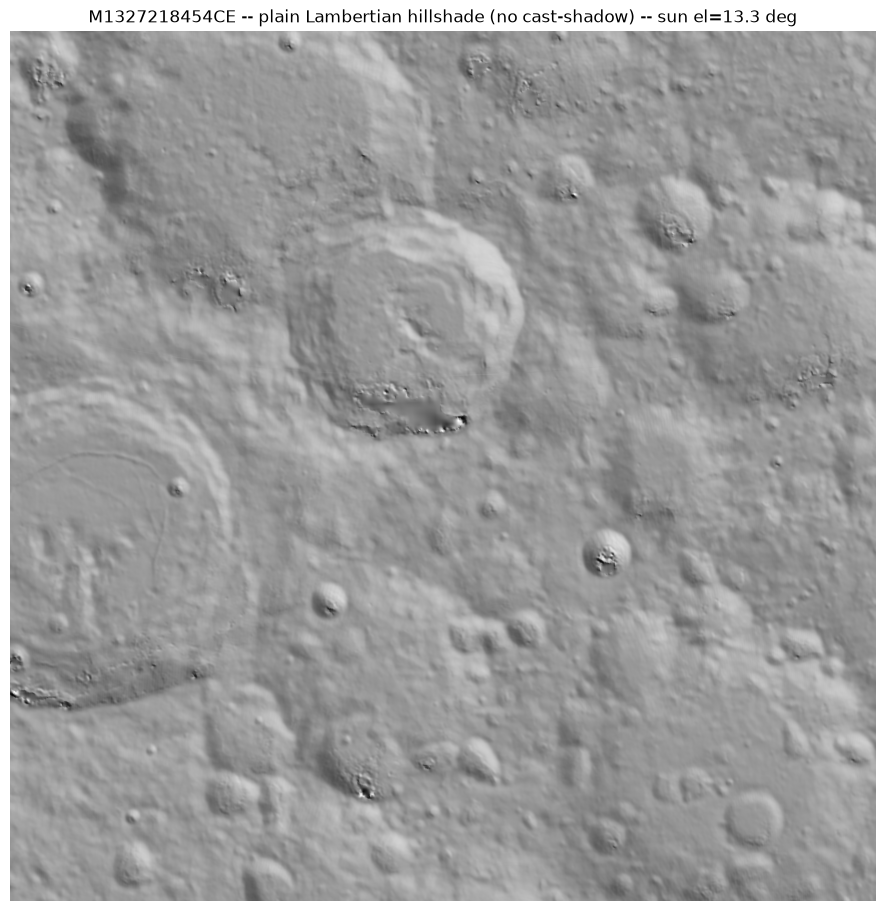

In [6]:
with rasterio.open(dem_result.dem) as src:
    elevation = src.read(1)
    pixel_resolution_m = src.res[0]

light = LightSource(azdeg=azimuth_deg, altdeg=elevation_deg)
plain_hillshade = light.hillshade(elevation.astype(np.float64), dx=pixel_resolution_m, dy=pixel_resolution_m)

fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)
ax.imshow(plain_hillshade, cmap="gray")
ax.set_title(f"{entry.edr_product} -- plain Lambertian hillshade (no cast-shadow) -- sun el={elevation_deg:.1f} deg")
ax.axis("off")
png_path = spike_dir / f"{entry.edr_product}_dem_hillshade.png"
fig.savefig(png_path, dpi=150)
print(f"wrote {png_path}")

## If picking this back up later

- Check whether a newer ASP release fixes `sfs`'s DEM/image overlap check for a raw (non-
  mapprojected) perspective render like `sat_sim`'s own output -- the `mapproject` cross-check
  above would be the first thing to re-run to confirm the fix actually applies here.
- Consider filing an upstream issue against `NeoGeographyToolkit/StereoPipeline` with this
  notebook's exact repro (DEM + `sat_sim` render + CSM JSON, `--model-shadows
  --save-sim-intensity-only`, "no data for this DEM" despite `mapproject` finding real overlap).
- `docs/proposed-tasks/standalone-shadow-mask-tool.md`: a narrower alternative that sidesteps this
  blocker entirely -- port just `sfs`'s own shadow ray-tracer (`isInShadow`/`areInShadow`, ~60 lines,
  Apache-2.0) into a small standalone tool, rather than running the full `sfs` binary. Superseded in
  practice by `docs/proposed-tasks/sun-aligned-shadow-sweep.md`, a pure-Python reformulation of the
  same physical test needing no new tool or repo.
- Simpler alternative that doesn't depend on any external tool cooperating at all, already
  proposed in `docs/proposed-tasks/gld100-banding-artifact.md`'s "Next steps": ray-trace a specific
  marginal pixel (e.g. row 1016, col 1500 in `isis_shadow_spike.py`'s DEM grid) directly in Python
  -- sample the DEM's real surface height along the true 3D line-of-sight toward the Sun to find
  (or rule out) a real occluding terrain feature. Answers this investigation's actual open
  question (is the row-1016-type streak real occlusion, or some ISIS-`shadow`-specific quirk)
  without needing a second full shadow-casting tool integrated at all.